In [5]:
!pip install numpy librosa sounddevice soundfile joblib
!python.exe -m pip install --upgrade pip

Loading model from: D:\project\ml_notebook_emotion_voice_speech\best_emotion_model.pkl
Loading feature scaler from: D:\project\ml_notebook_emotion_voice_speech\feature_scaler.pkl

Initialization successful.
Recordings folder: D:\project\ml_notebook_emotion_voice_speech\recordings
Model classes: [0 1 2 3]
Scaler expects 67 features.

MICROPHONE RECORDING
Duration    : 5.0 seconds
Sample Rate : 22050

Speak now...
Recording completed successfully.

Checking for speech...

ANALYZING AUDIO
Estimated speech duration: 5.02 seconds

EMOTION DETECTION RESULT

Emotion    : joyfully
Confidence : 30.87%
Speech     : 5.02s

Emotion probabilities:
  surprised         30.87%
  sad               24.50%
  joyfully          23.59%
  euphoric          21.04%



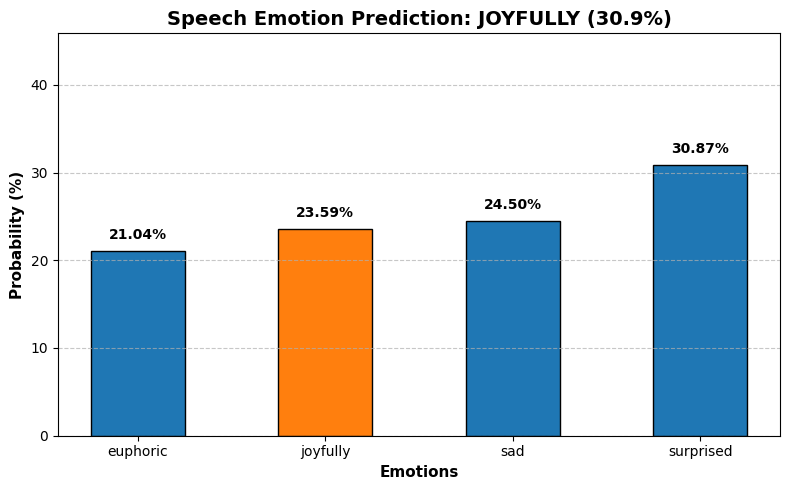


Final result dictionary:
{'success': True, 'emotion': 'joyfully', 'confidence': 0.3086513812693539, 'confidence_scores': {'euphoric': 0.2104360053858209, 'joyfully': 0.23586648018518386, 'sad': 0.2450461331596416, 'surprised': 0.3086513812693539}, 'speech_detected': True, 'speech_duration': 5.015510204081632, 'message': 'Emotion prediction successful.', 'audio_path': 'D:\\project\\ml_notebook_emotion_voice_speech\\recordings\\emotion_recording_20260924_140429_003465.wav'}


In [17]:
import os
import time
from datetime import datetime

import joblib
import numpy as np
import librosa
import sounddevice as sd
import soundfile as sf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Get absolute path of directory where this script resides
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
DEFAULT_MODEL_PATH = os.path.join(BASE_DIR, "best_emotion_model.pkl")
DEFAULT_SCALER_PATH = os.path.join(BASE_DIR, "feature_scaler.pkl")


class SpeechEmotionRecognizer:
    """
    Speech Emotion Recognition pipeline using:
        - Pre-trained ML or Deep Learning Model (.pkl / .h5 / .keras)
        - Feature scaler (.pkl)
        - Microphone recording via sounddevice
        - Basic Voice Activity Detection (VAD) / Speech gate
        - Matplotlib Bar Chart Visualization
    """

    def __init__(
        self,
        model_path=DEFAULT_MODEL_PATH,
        scaler_path=DEFAULT_SCALER_PATH,
        sample_rate=22050,
        duration=5.0,
        delete_audio=False
    ):
        self.model_path = model_path
        self.scaler_path = scaler_path
        self.sample_rate = sample_rate
        self.duration = duration
        self.delete_audio = delete_audio

        # Validate file existence before proceeding
        if not os.path.exists(self.model_path):
            raise FileNotFoundError(
                f"\n[ERROR] Model file not found at: {self.model_path}\n"
                f"Please ensure '{os.path.basename(self.model_path)}' exists in directory: {os.path.dirname(self.model_path)}"
            )

        if not os.path.exists(self.scaler_path):
            raise FileNotFoundError(
                f"\n[ERROR] Scaler file not found at: {self.scaler_path}\n"
                f"Please ensure '{os.path.basename(self.scaler_path)}' exists in directory: {os.path.dirname(self.scaler_path)}"
            )

        # Load Model
        print(f"Loading model from: {self.model_path}")
        if self.model_path.endswith(".h5") or self.model_path.endswith(".keras"):
            try:
                import tensorflow as tf
                self.model = tf.keras.models.load_model(self.model_path)
                self.is_keras_model = True
            except ImportError:
                raise ImportError("TensorFlow is required to load .h5 / .keras models.")
        else:
            self.model = joblib.load(self.model_path)
            self.is_keras_model = False

        # Load Scaler
        print(f"Loading feature scaler from: {self.scaler_path}")
        self.scaler = joblib.load(self.scaler_path)

        # Class / Label Mapping
        self.emotion_map = {
            0: "euphoric",
            1: "joyfully",
            2: "sad",
            3: "surprised"
        }

        self.recordings_dir = self.get_recordings_directory()

        print("\nInitialization successful.")
        print(f"Recordings folder: {self.recordings_dir}")

        # Log Model Meta Info
        if not self.is_keras_model and hasattr(self.model, "classes_"):
            print(f"Model classes: {self.model.classes_}")

        if hasattr(self.scaler, "n_features_in_"):
            print(f"Scaler expects {self.scaler.n_features_in_} features.")

    def get_recordings_directory(self):
        """Get or create the recording output directory safely."""
        recordings_dir = os.path.join(BASE_DIR, "recordings")
        os.makedirs(recordings_dir, exist_ok=True)
        return recordings_dir

    def create_audio_path(self):
        """Generate unique timestamped WAV filename."""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        return os.path.join(self.recordings_dir, f"emotion_recording_{timestamp}.wav")

    def record_audio(self, audio_path, duration=None):
        """Record live microphone input and write to a WAV file."""
        if duration is None:
            duration = self.duration

        print("\n" + "=" * 60)
        print("MICROPHONE RECORDING")
        print("=" * 60)
        print(f"Duration    : {duration} seconds")
        print(f"Sample Rate : {self.sample_rate}")
        print("\nSpeak now...")

        try:
            recording = sd.rec(
                int(duration * self.sample_rate),
                samplerate=self.sample_rate,
                channels=1,
                dtype="float32"
            )
            sd.wait()
        except Exception as e:
            raise RuntimeError(f"Microphone recording failed: {e}")

        try:
            sf.write(audio_path, recording, self.sample_rate)
        except Exception as e:
            raise RuntimeError(f"Could not save audio file: {e}")

        print("Recording completed successfully.")
        return audio_path

    def load_audio(self, audio_path):
        """Load audio file and Pad/Truncate to target duration."""
        if not os.path.exists(audio_path):
            raise FileNotFoundError(f"Audio file not found: {audio_path}")

        try:
            audio, sr = librosa.load(
                audio_path,
                sr=self.sample_rate,
                duration=self.duration,
                mono=True
            )
        except Exception as e:
            raise RuntimeError(f"Could not load audio file: {e}")

        target_length = int(self.sample_rate * self.duration)

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)), mode="constant")
        elif len(audio) > target_length:
            audio = audio[:target_length]

        return audio.astype(np.float32), sr

    def has_speech(self, audio):
        """Check if audio signal contains enough active speech energy."""
        audio = np.asarray(audio, dtype=np.float32)
        if len(audio) == 0:
            return False

        audio = audio - np.mean(audio)
        rms = np.sqrt(np.mean(np.square(audio)))
        max_amplitude = np.max(np.abs(audio))

        if max_amplitude < 0.003 or rms < 0.005:
            return False

        frame_length, hop_length = 1024, 512
        rms_frames = librosa.feature.rms(
            y=audio,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]

        if len(rms_frames) == 0:
            return False

        rms_db = librosa.amplitude_to_db(rms_frames, ref=np.max)
        active_ratio = np.mean(rms_db > -35)

        if active_ratio < 0.15:
            return False

        zcr = librosa.feature.zero_crossing_rate(
            audio,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]

        if np.mean(zcr) < 0.005 and rms < 0.01:
            return False

        return True

    def get_speech_duration(self, audio):
        """Estimate the total duration of detected active speech in seconds."""
        frame_length, hop_length = 1024, 512
        rms_frames = librosa.feature.rms(
            y=audio,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]

        if len(rms_frames) == 0:
            return 0.0

        rms_db = librosa.amplitude_to_db(rms_frames, ref=np.max)
        active_count = np.sum(rms_db > -35)

        return float((active_count * hop_length) / self.sample_rate)

    def extract_features(self, audio_path):
        """Extract acoustic audio features."""
        audio, sr = self.load_audio(audio_path)
        features = []

        # MFCCs (20 Mean + 20 Std = 40)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20, n_fft=2048, hop_length=512)
        features.extend(np.mean(mfcc, axis=1))
        features.extend(np.std(mfcc, axis=1))

        # Spectral Centroid (2)
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
        features.append(np.mean(spectral_centroid))
        features.append(np.std(spectral_centroid))

        # Spectral Rolloff (2)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
        features.append(np.mean(spectral_rolloff))
        features.append(np.std(spectral_rolloff))

        # Zero Crossing Rate (2)
        zcr = librosa.feature.zero_crossing_rate(audio)
        features.append(np.mean(zcr))
        features.append(np.std(zcr))

        # RMS Energy (2)
        rms = librosa.feature.rms(y=audio)
        features.append(np.mean(rms))
        features.append(np.std(rms))

        # Chroma (12)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        features.extend(np.mean(chroma, axis=1))

        # Spectral Contrast (7)
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
        features.extend(np.mean(contrast, axis=1))

        features = np.asarray(features, dtype=np.float32)

        # Validate extracted shape against fitted scaler expectation
        expected_features = getattr(self.scaler, "n_features_in_", None)
        if expected_features is not None and len(features) != expected_features:
            raise ValueError(
                f"\nFeature Mismatch!\nExtracted: {len(features)} features\n"
                f"Scaler expects: {expected_features} features."
            )

        return features

    def predict_emotion(self, audio_path, check_speech=True):
        """Run feature extraction and inference on a saved WAV audio file."""
        print("\n" + "=" * 60)
        print("ANALYZING AUDIO")
        print("=" * 60)

        audio, _ = self.load_audio(audio_path)

        if check_speech and not self.has_speech(audio):
            return {
                "success": False,
                "emotion": None,
                "confidence": 0.0,
                "confidence_scores": {},
                "speech_detected": False,
                "speech_duration": 0.0,
                "message": "No meaningful speech detected."
            }

        speech_duration = self.get_speech_duration(audio)
        print(f"Estimated speech duration: {speech_duration:.2f} seconds")

        if speech_duration < 0.5:
            return {
                "success": False,
                "emotion": None,
                "confidence": 0.0,
                "confidence_scores": {},
                "speech_detected": True,
                "speech_duration": speech_duration,
                "message": "Speech detected, but segment is too short."
            }

        features = self.extract_features(audio_path)
        scaled_features = self.scaler.transform(features.reshape(1, -1))

        confidence_scores = {}

        if self.is_keras_model:
            probabilities = self.model.predict(scaled_features, verbose=0)[0]
            prediction_id = int(np.argmax(probabilities))
            confidence = float(np.max(probabilities))

            for idx, prob in enumerate(probabilities):
                emotion_name = self.emotion_map.get(idx, str(idx))
                confidence_scores[emotion_name] = float(prob)
        else:
            prediction = self.model.predict(scaled_features)[0]
            try:
                prediction_id = int(prediction)
            except (ValueError, TypeError):
                prediction_id = prediction

            if hasattr(self.model, "predict_proba"):
                try:
                    probabilities = self.model.predict_proba(scaled_features)[0]
                    class_ids = getattr(self.model, "classes_", range(len(probabilities)))
                    for class_id, prob in zip(class_ids, probabilities):
                        try:
                            cid = int(class_id)
                        except (ValueError, TypeError):
                            cid = class_id
                        emotion_name = self.emotion_map.get(cid, str(class_id))
                        confidence_scores[emotion_name] = float(prob)
                    confidence = float(np.max(probabilities))
                except Exception as e:
                    print(f"Warning: Probability calculation failed: {e}")
                    confidence = 0.0
            else:
                confidence = 0.0

        emotion = self.emotion_map.get(prediction_id, str(prediction_id))

        return {
            "success": True,
            "emotion": emotion,
            "confidence": confidence,
            "confidence_scores": confidence_scores,
            "speech_detected": True,
            "speech_duration": speech_duration,
            "message": "Emotion prediction successful."
        }

    def predict_from_microphone(self, duration=None, delete_audio=None, show_graph=True):
        """Capture microphone stream, run inference, and optionally display a graph."""
        if duration is None:
            duration = self.duration
        if delete_audio is None:
            delete_audio = self.delete_audio

        audio_path = self.create_audio_path()

        try:
            self.record_audio(audio_path, duration)
            audio, _ = self.load_audio(audio_path)

            print("\nChecking for speech...")
            if not self.has_speech(audio):
                print("\n" + "=" * 60)
                print("NO SPEECH DETECTED")
                print("=" * 60)
                return {
                    "success": False,
                    "emotion": None,
                    "confidence": 0.0,
                    "confidence_scores": {},
                    "speech_detected": False,
                    "speech_duration": 0.0,
                    "audio_path": audio_path,
                    "message": "No meaningful speech detected."
                }

            speech_duration = self.get_speech_duration(audio)
            if speech_duration < 0.5:
                print("\n" + "=" * 60)
                print("SPEECH TOO SHORT")
                print("=" * 60)
                return {
                    "success": False,
                    "emotion": None,
                    "confidence": 0.0,
                    "confidence_scores": {},
                    "speech_detected": True,
                    "speech_duration": speech_duration,
                    "audio_path": audio_path,
                    "message": "Speech detected, but recording was too short."
                }

            result = self.predict_emotion(audio_path, check_speech=False)
            result["audio_path"] = audio_path
            self.display_result(result)

            if show_graph and result.get("success", False):
                self.plot_emotion_probabilities(result)

            return result

        finally:
            if delete_audio and os.path.exists(audio_path):
                self.delete_audio_file(audio_path)

    def plot_emotion_probabilities(self, result, save_path=None):
        """Generates a bar plot showing probability breakdown per emotion class."""
        scores = result.get("confidence_scores", {})
        predicted_emotion = result.get("emotion")

        if not scores:
            print("No probability scores available to plot.")
            return

        emotions = list(scores.keys())
        percentages = [scores[e] * 100 for e in emotions]

        # Define custom color palette (highlighting the top predicted emotion)
        colors = ["#1f77b4" if e != predicted_emotion else "#ff7f0e" for e in emotions]

        plt.figure(figsize=(8, 5))
        bars = plt.bar(emotions, percentages, color=colors, edgecolor="black", width=0.5)

        # Annotate percentages above bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                yval + 1.0,
                f"{yval:.2f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

        plt.title(f"Speech Emotion Prediction: {predicted_emotion.upper()} ({result['confidence']*100:.1f}%)", fontsize=14, fontweight="bold")
        plt.xlabel("Emotions", fontsize=11, fontweight="bold")
        plt.ylabel("Probability (%)", fontsize=11, fontweight="bold")
        plt.ylim(0, max(percentages) + 15)
        plt.grid(axis="y", linestyle="--", alpha=0.7)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300)
            print(f"Graph saved to: {save_path}")

        plt.show()

    def delete_audio_file(self, audio_path):
        """Safely delete an audio file."""
        try:
            os.remove(audio_path)
            print(f"\nAudio deleted:\n{audio_path}")
        except Exception as e:
            print(f"\nCould not delete audio file: {e}")

    def display_result(self, result):
        """Print structured output in the console."""
        print("\n" + "=" * 60)
        print("EMOTION DETECTION RESULT")
        print("=" * 60)

        if not result.get("success", False):
            print("\nStatus : FAILED")
            print(f"Reason : {result.get('message', 'Unknown error')}")
            return

        print(f"\nEmotion    : {result.get('emotion')}")
        print(f"Confidence : {result.get('confidence', 0.0) * 100:.2f}%")
        print(f"Speech     : {result.get('speech_duration', 0):.2f}s")

        confidence_scores = result.get("confidence_scores", {})
        if confidence_scores:
            print("\nEmotion probabilities:")
            sorted_scores = sorted(
                confidence_scores.items(), key=lambda x: x[1], reverse=True
            )
            for emotion_name, prob in sorted_scores:
                print(f"  {emotion_name:<15} {prob * 100:>7.2f}%")

        print("\n" + "=" * 60)


if __name__ == "__main__":
    try:
        recognizer = SpeechEmotionRecognizer(
            model_path=DEFAULT_MODEL_PATH,
            scaler_path=DEFAULT_SCALER_PATH,
            sample_rate=22050,
            duration=5.0,
            delete_audio=False
        )

        result = recognizer.predict_from_microphone(
            duration=5.0,
            delete_audio=False,
            show_graph=True  # Displays the pop-up Matplotlib graph window
        )

        print("\nFinal result dictionary:")
        print(result)

    except KeyboardInterrupt:
        print("\n\nProgram interrupted by user.")
    except Exception as e:
        print(f"\n\nERROR: {e}")